# Домашнее задание "Варианционные автоэнкодеры"

В этом домашнем задании вам предстоит реализовать несколько версий автоэнкодера для работы с изображениями.

Вы научитесь добавлять улыбку на фотографии людей, изменяя их исходное выражение лица с помощью обученной модели. А также, обучите ваш автоэнкодер генерировать изображения рукописных цифр.

# Часть 1. Vanilla Autoencoder (10 баллов)

## 1.1. Подготовка данных (1 балл)


Перед тем, как начинать работу с моделями нужно подготовить данные.

In [3]:
import numpy as np
from torch.autograd import Variable
from torchvision import datasets
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data_utils
import torch
import matplotlib.pyplot as plt

import os
import pandas as pd
import skimage.io
from skimage.transform import resize

import imageio
from PIL import Image
import kagglehub

%matplotlib inline

В этом задании вам предстоить работать с датасетом [LFW (Labeled Faces in the Wild)](https://datasets.activeloop.ai/docs/ml/datasets/lfw-dataset/#:~:text=What%20is%20LFW%20Dataset%3F,commercial%20algorithms%20prior%20to%20release).

In [4]:
# Скачиваем картинки
images_path = kagglehub.dataset_download("jessicali9530/lfw-dataset")
print("Path to dataset files:", images_path)

100%|██████████| 112M/112M [00:58<00:00, 2.00MB/s] 

Extracting files...


Path to dataset files: /Users/samtakot/.cache/kagglehub/datasets/jessicali9530/lfw-dataset/versions/4


In [5]:
# Скачиваем атрибуты
attrs_path = kagglehub.dataset_download("averkij/lfw-attributes")
print("Path to dataset files:", attrs_path)

100%|██████████| 6.49M/6.49M [00:05<00:00, 1.26MB/s]

Extracting files...


Path to dataset files: /Users/samtakot/.cache/kagglehub/datasets/averkij/lfw-attributes/versions/1


In [191]:
# DATASET_PATH ="/kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled/"
# ATTRIBUTES_PATH = "/kaggle/input/lfw-attributes/lfw_attributes.txt"
DATASET_PATH = "/Users/samtakot/.cache/kagglehub/datasets/jessicali9530/lfw-dataset/versions/4/lfw-deepfunneled/lfw-deepfunneled"
ATTRIBUTES_PATH = "/Users/samtakot/.cache/kagglehub/datasets/averkij/lfw-attributes/versions/1/lfw_attributes.txt"


In [192]:
def fetch_dataset(dx=80, dy=80, dimx=45, dimy=45):

    df_attrs = pd.read_csv(ATTRIBUTES_PATH, sep='\t', skiprows=1,)
    df_attrs = pd.DataFrame(df_attrs.iloc[:, :-1].values, columns = df_attrs.columns[1:])

    photo_ids = []
    for dirpath, dirnames, filenames in os.walk(DATASET_PATH):
        for fname in filenames:
            if fname.endswith(".jpg"):
                fpath = os.path.join(dirpath, fname)
                photo_id = fname[:-4].replace('_', ' ').split()
                person_id = ' '.join(photo_id[:-1])
                photo_number = int(photo_id[-1])
                photo_ids.append({'person': person_id,'imagenum': photo_number, 'photo_path': fpath})

    photo_ids = pd.DataFrame(photo_ids)
    df = pd.merge(df_attrs,photo_ids,on=('person', 'imagenum'))

    assert len(df) == len(df_attrs), "Потеряны данные при объединении датафреймов!"

    images = df['photo_path'].apply(imageio.imread)\
                                .apply(lambda img:img[dy:-dy, dx:-dx])\
                                .apply(lambda img: np.array(Image.fromarray(img).resize([dimx, dimy])) )

    images = np.stack(images.values).astype('uint8')
    attrs = df.drop(["photo_path","person","imagenum"],axis=1)

    return images, attrs

In [193]:
# Обратите внимание, что датасет представляет собой не только картинки, но и атрибуты
# Атрибуты понадобятся в конце этого задания

images, attrs = fetch_dataset()


Разбейте датасет изображений и атрибутов на train и val, выведите несколько картинок в output, чтобы посмотреть, как они выглядят, и приведите картинки к тензорам pytorch, чтобы можно было скормить их сети:

In [194]:
# Mac, NVIDIA и CPU
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"device: {device}")

device: mps


In [195]:
# <тут Ваш код>
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)

from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

X_train, X_val, attrs_train, attrs_val = train_test_split(
    images,
    attrs,
    train_size=0.9, shuffle=False, random_state=RANDOM_SEED)

#print(attrs_train.dtypes)
#print(attrs_train.head())

# uint8 → float32 в диапазоне [0, 1]
X_train = X_train.astype('float32') / 255.0
X_val   = X_val.astype('float32') / 255.0

# (N, H, W, C) → (N, C, H, W) — PyTorch формат каналов
X_train = torch.from_numpy(X_train).permute(0, 3, 1, 2)
X_val   = torch.from_numpy(X_val).permute(0, 3, 1, 2)

def make_loader(X, attrs_df, batch_size=32, shuffle=False):
    attrs_t = torch.from_numpy(attrs_df.astype('float32').values)
    ds = TensorDataset(X, attrs_t)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


train_loader = make_loader(X_train, attrs_train, shuffle=True)
val_loader   = make_loader(X_val, attrs_val, shuffle=False)

#

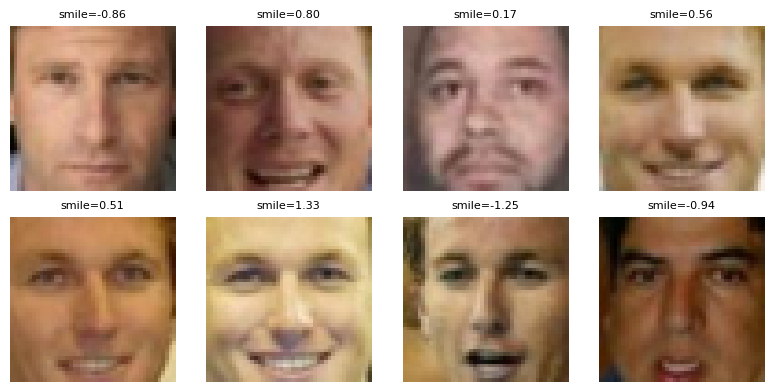

In [196]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(8, 4))
for i, ax in enumerate(axes.flat):
    img = X_train[i].permute(1, 2, 0).numpy()
    ax.imshow(img)
    male = "M" if attrs_train.iloc[i]['Male'] > 0 else "F"
    smile_score = attrs_train.iloc[i]['Smiling']
    ax.set_title(f"smile={smile_score:.2f}", fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

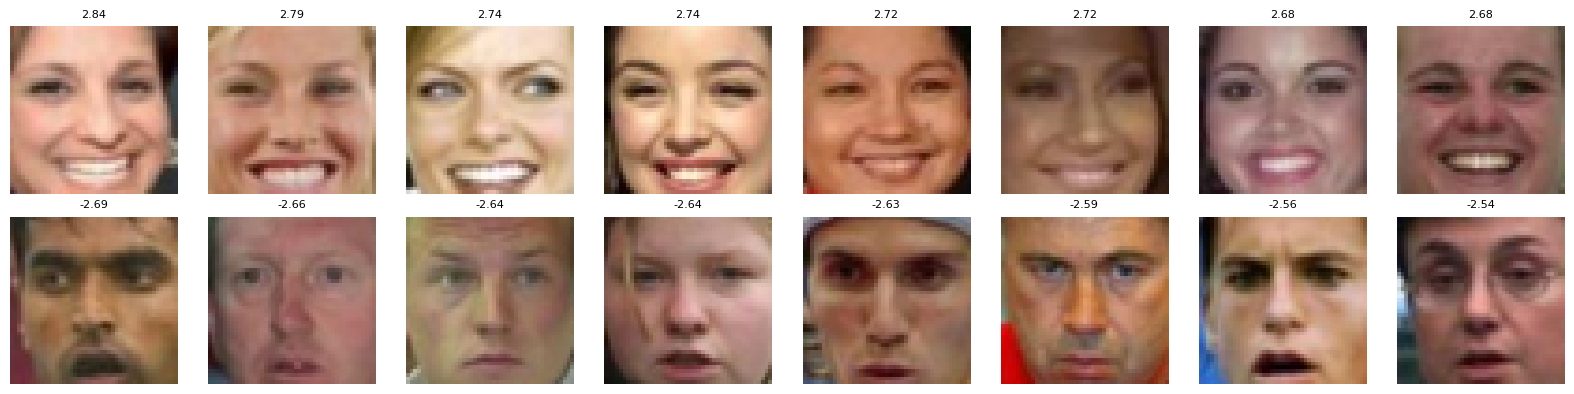

In [197]:
import matplotlib.pyplot as plt

scores = attrs_train['Smiling'].values
top    = scores.argsort()[-8:][::-1]   # 8 самых улыбающихся
bottom = scores.argsort()[:8]          # 8 самых неулыбающихся

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for j, idx in enumerate(top):
    axes[0, j].imshow(X_train[idx].permute(1, 2, 0).numpy())
    axes[0, j].set_title(f"{scores[idx]:.2f}", fontsize=8)
    axes[0, j].axis('off')
for j, idx in enumerate(bottom):
    axes[1, j].imshow(X_train[idx].permute(1, 2, 0).numpy())
    axes[1, j].set_title(f"{scores[idx]:.2f}", fontsize=8)
    axes[1, j].axis('off')
axes[0, 0].set_ylabel('Top smile')
axes[1, 0].set_ylabel('No smile')
plt.tight_layout(); plt.show()

## 1.2. Архитектура модели (2 балла)
В этом разделе вы напишите и обучите обычный автоэнкодер.


In [198]:
dim_code = 256 # выберите размер латентного вектора

Реализуем autoencoder. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Экспериментируйте!

In [199]:
class Autoencoder(nn.Module):
    def __init__(self, dim_code):
        super().__init__()
        # <определите архитектуры encoder и decoder>

        # Входная картинка (3, 45, 45)
        self.encoder = nn.Sequential(

            nn.Conv2d(3, 32, 3, stride = 2, padding = 1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride = 2, padding = 1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride = 2, padding = 1),
            nn.ReLU(),
            # переводим из "feature map" в плоский latent вектор размера dim_code
            nn.Flatten(),
            nn.Linear(128*6*6, dim_code),
        )

        # Энкодер: 45 → 23 → 12 → 6 (с округлением вниз) поэтому добавим output_padding=1
        self.decoder = nn.Sequential(
            nn.Linear(dim_code, 128*6*6),
            nn.ReLU(), # Под вопросом - занулит отрицательные векторы
            nn.Unflatten(1, (128, 6, 6)),
            nn.ConvTranspose2d(128, 64, 3, stride = 2, padding = 1, output_padding=1),
            nn.ReLU(),
            # nn.Dropout2d(0.2), 
            nn.ConvTranspose2d(64, 32, 3, stride = 2, padding = 1, output_padding=0),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 3, stride = 2, padding = 1, output_padding=0),
            nn.Sigmoid()
        )

    def forward(self, x):
        # реализуйте forward проход автоэнкодера
        # в качестве возвращаемых переменных -- латентное представление картинки (latent_code)
        # и полученная реконструкция изображения (reconstruction)

        latent_code = self.encoder(x)
        # x = self.decoder_fc(latent_code).view(-1, 128, 6, 6)
        reconstruction = self.decoder(latent_code)

        return reconstruction, latent_code

In [200]:
ae = Autoencoder(dim_code=dim_code)
rec, z = ae(torch.randn(2, 3, 45, 45))
print(rec.shape, z.shape)

torch.Size([2, 3, 45, 45]) torch.Size([2, 256])


In [201]:
import gc
# почистим память перед обучением
gc.collect()
torch.mps.empty_cache()  

print(f"Allocated: {torch.mps.current_allocated_memory() / 1024**3:.2f} GiB")
print(f"Driver: {torch.mps.driver_allocated_memory() / 1024**3:.2f} GiB") 

# подмешаем L1 для улучшения резкости - но честно говоря визуально не очень понятно - как помогает (пробовал weight 0.1 и 0.4)
class MSEPlusL1(nn.Module):
    def __init__(self, l1_weight):
        super().__init__()
        self.mse = nn.MSELoss()
        self.l1  = nn.L1Loss()
        
        self.l1_weight = l1_weight

    def forward(self, rec, x):
        return self.mse(rec, x) + self.l1_weight * self.l1(rec, x)

criterion = MSEPlusL1(l1_weight=0.1)

autoencoder = Autoencoder(dim_code=dim_code).to(device)

optimizer = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)

Allocated: 0.06 GiB
Driver: 0.14 GiB


## 1.3 Обучение (2 балла)

Осталось написать код обучения автоэнкодера. При этом было бы неплохо в процессе иногда смотреть, как автоэнкодер реконструирует изображения на данном этапе обучения. Наример, после каждой эпохи (прогона train выборки через автоэнкодер) можно смотреть, какие реконструкции получились для каких-то изображений val выборки.

А, ну еще было бы неплохо выводить графики train и val лоссов в процессе тренировки =)

In [202]:
def show_reconstructions(model, loader, n, device ):
    model.eval()
    with torch.no_grad():
        X, _ = next(iter(loader))
        X = X[:n].to(device)
        rec, _ = model(X)
    fig, axes = plt.subplots(2, n, figsize=(n*1.5, 3))
    for i in range(n):
        axes[0, i].imshow(X[i].cpu().permute(1, 2, 0).numpy());   axes[0, i].axis('off')
        axes[1, i].imshow(rec[i].cpu().permute(1, 2, 0).numpy()); axes[1, i].axis('off')
    axes[0, 0].set_ylabel('orig'); axes[1, 0].set_ylabel('rec')
    plt.tight_layout(); plt.show()


In [203]:
# добавление шума для бонусного задания
def add_noise(X, factor):
    if factor <= 0:
        return X
    return torch.clamp(X + factor * torch.randn_like(X), 0, 1)


In [204]:
from tqdm.notebook import tqdm


n_epochs = 60


def train_all(
        autoencoder, 
        train_loader, 
        val_loader,
        n_epochs,
        
        noise_factor=0.0, # для. бонусной задачи с шумом
        save_path='best_ae.pt',
        verbose=True
):
    train_losses, val_losses = [], []
    best_val = float('inf')
    for epoch in tqdm(range(n_epochs), desc="Epochs"):
        autoencoder.train()
        train_loss = 0
        for X_batch, _ in tqdm(train_loader, desc=f"epoch {epoch+1}", leave=False):
            X_batch = X_batch.to(device)
            X_input = add_noise(X_batch, noise_factor)

            optimizer.zero_grad()
            reconstruction, _ = autoencoder(X_input)
            loss = criterion(reconstruction, X_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
        train_loss /= len(train_loader.dataset)
        train_losses.append(train_loss)

        autoencoder.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, _ in val_loader:
                X_batch = X_batch.to(device)
                X_input = add_noise(X_batch, noise_factor)
                
                reconstruction, _ = autoencoder(X_input)
                loss = criterion(reconstruction, X_batch)
                val_loss += loss.item() * X_batch.size(0)
        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}/{n_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

        if val_loss < best_val:
            best_val = val_loss
            torch.save(autoencoder.state_dict(), save_path)

        #
        if (epoch + 1) % 10 == 0 and verbose:
            show_reconstructions(autoencoder, val_loader, n=4, device=device)

    return train_losses, val_losses



Epochs:   0%|          | 0/60 [00:00<?, ?it/s]

epoch 1:   0%|          | 0/370 [00:00<?, ?it/s]

Epoch 1/60, Train Loss: 0.0220, Val Loss: 0.0126


epoch 2:   0%|          | 0/370 [00:00<?, ?it/s]

Epoch 2/60, Train Loss: 0.0106, Val Loss: 0.0092


...

Epoch 8/60, Train Loss: 0.0054, Val Loss: 0.0056


epoch 9:   0%|          | 0/370 [00:00<?, ?it/s]

Epoch 9/60, Train Loss: 0.0051, Val Loss: 0.0052


epoch 10:   0%|          | 0/370 [00:00<?, ?it/s]

Epoch 10/60, Train Loss: 0.0049, Val Loss: 0.0050


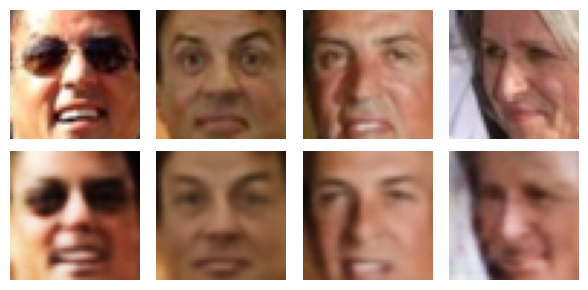

epoch 11:   0%|          | 0/370 [00:00<?, ?it/s]

Epoch 11/60, Train Loss: 0.0048, Val Loss: 0.0049


epoch 12:   0%|          | 0/370 [00:00<?, ?it/s]

Epoch 12/60, Train Loss: 0.0047, Val Loss: 0.0049


epoch 13:   0%|          | 0/370 [00:00<?, ?it/s]

...

Epoch 18/60, Train Loss: 0.0040, Val Loss: 0.0042


epoch 19:   0%|          | 0/370 [00:00<?, ?it/s]

Epoch 19/60, Train Loss: 0.0039, Val Loss: 0.0043


epoch 20:   0%|          | 0/370 [00:00<?, ?it/s]

Epoch 20/60, Train Loss: 0.0038, Val Loss: 0.0041


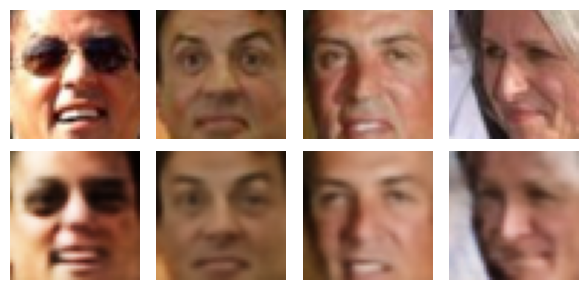

epoch 21:   0%|          | 0/370 [00:00<?, ?it/s]

Epoch 21/60, Train Loss: 0.0038, Val Loss: 0.0041


epoch 22:   0%|          | 0/370 [00:00<?, ?it/s]

Epoch 22/60, Train Loss: 0.0038, Val Loss: 0.0048


epoch 23:   0%|          | 0/370 [00:00<?, ?it/s]

...

Epoch 28/60, Train Loss: 0.0036, Val Loss: 0.0039


epoch 29:   0%|          | 0/370 [00:00<?, ?it/s]

Epoch 29/60, Train Loss: 0.0035, Val Loss: 0.0038


epoch 30:   0%|          | 0/370 [00:00<?, ?it/s]

Epoch 30/60, Train Loss: 0.0035, Val Loss: 0.0038


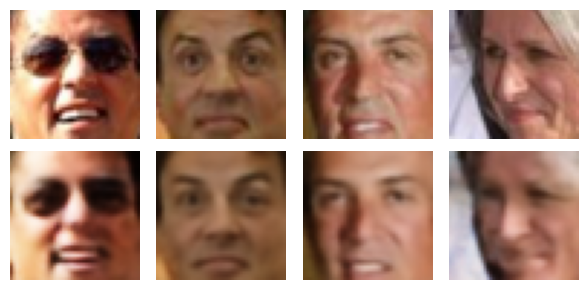

epoch 31:   0%|          | 0/370 [00:00<?, ?it/s]

Epoch 31/60, Train Loss: 0.0034, Val Loss: 0.0039


epoch 32:   0%|          | 0/370 [00:00<?, ?it/s]

Epoch 32/60, Train Loss: 0.0034, Val Loss: 0.0040


epoch 33:   0%|          | 0/370 [00:00<?, ?it/s]

...

Epoch 38/60, Train Loss: 0.0033, Val Loss: 0.0038


epoch 39:   0%|          | 0/370 [00:00<?, ?it/s]

Epoch 39/60, Train Loss: 0.0033, Val Loss: 0.0038


epoch 40:   0%|          | 0/370 [00:00<?, ?it/s]

Epoch 40/60, Train Loss: 0.0033, Val Loss: 0.0038


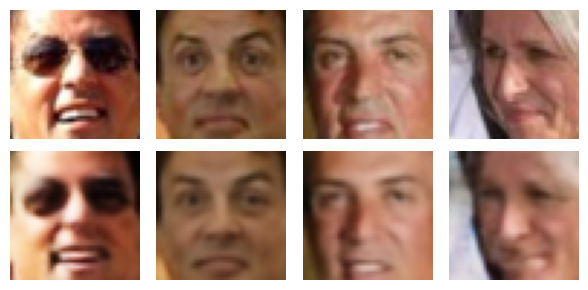

epoch 41:   0%|          | 0/370 [00:00<?, ?it/s]

Epoch 41/60, Train Loss: 0.0033, Val Loss: 0.0038


epoch 42:   0%|          | 0/370 [00:00<?, ?it/s]

Epoch 42/60, Train Loss: 0.0033, Val Loss: 0.0039


epoch 43:   0%|          | 0/370 [00:00<?, ?it/s]

...

Epoch 48/60, Train Loss: 0.0032, Val Loss: 0.0038


epoch 49:   0%|          | 0/370 [00:00<?, ?it/s]

Epoch 49/60, Train Loss: 0.0032, Val Loss: 0.0038


epoch 50:   0%|          | 0/370 [00:00<?, ?it/s]

Epoch 50/60, Train Loss: 0.0032, Val Loss: 0.0037


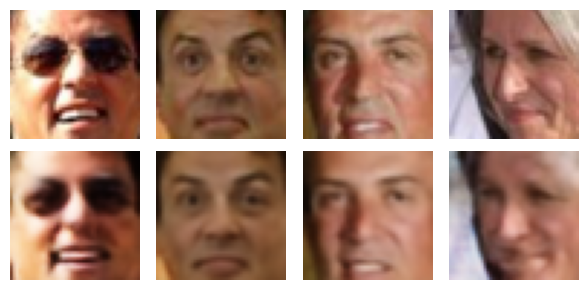

epoch 51:   0%|          | 0/370 [00:00<?, ?it/s]

Epoch 51/60, Train Loss: 0.0031, Val Loss: 0.0038


epoch 52:   0%|          | 0/370 [00:00<?, ?it/s]

Epoch 52/60, Train Loss: 0.0031, Val Loss: 0.0037


epoch 53:   0%|          | 0/370 [00:00<?, ?it/s]

...

Epoch 58/60, Train Loss: 0.0031, Val Loss: 0.0037


epoch 59:   0%|          | 0/370 [00:00<?, ?it/s]

Epoch 59/60, Train Loss: 0.0031, Val Loss: 0.0037


epoch 60:   0%|          | 0/370 [00:00<?, ?it/s]

Epoch 60/60, Train Loss: 0.0031, Val Loss: 0.0038


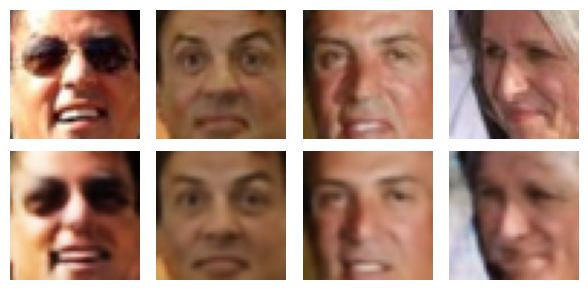

In [ ]:
train_losses, val_losses = train_all(
    autoencoder,
    train_loader, 
    val_loader, 
    n_epochs=n_epochs, 
    noise_factor=0,
    save_path='best_ae.pt',
    verbose=True
)

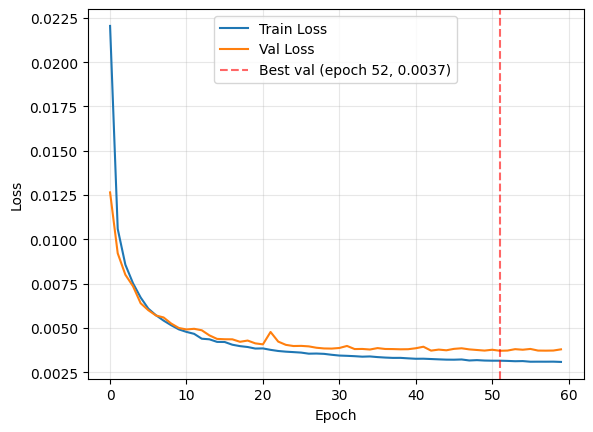

In [206]:
import numpy as np

best_epoch = int(np.argmin(val_losses))

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.axvline(best_epoch, color='red', linestyle='--', alpha=0.6,
            label=f'Best val (epoch {best_epoch+1}, {val_losses[best_epoch]:.4f})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Давайте посмотрим, как наш тренированный автоэнкодер кодирует и восстанавливает картинки:

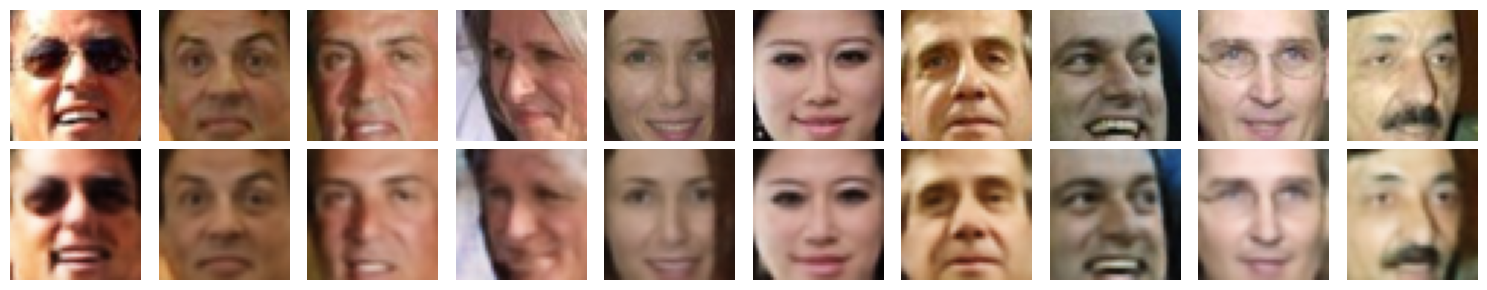

In [207]:
autoencoder.load_state_dict(torch.load('best_ae.pt'))
autoencoder.eval()

show_reconstructions(autoencoder, val_loader, n=10, device=device)



Что вы можете сказать про результат?

Результат: картинки размытые, есть артефакты.

Если увеличивать размерность латента с 128 до 256 - то модель учится дольше, итоговый лосс меньше и качество лучше.


## 1.4. Sampling (2 балла)

Давайте теперь будем не просто брать картинку, прогонять ее через автоэнкодер и получать реконструкцию, а попробуем создать что-то НОВОЕ!

Давайте возьмем и подсунем декодеру какие-нибудь сгенерированные нами векторы (например, из нормального распределения) и посмотрим на результат реконструкции декодера:

__Подсказка:__ Если вместо лиц у вас выводится непонятно что, попробуйте посмотреть, как выглядят латентные векторы картинок из датасета. Так как в обучении нейронных сетей есть определенная доля рандома, векторы латентного слоя могут быть распределены НЕ как `np.random.randn(25, <latent_space_dim>)`. А чтобы у нас получались лица при запихивании вектора декодеру, вектор должен быть распределен так же, как латентные векторы реальных фоток. Так что в таком случае придется рандом немного подогнать.

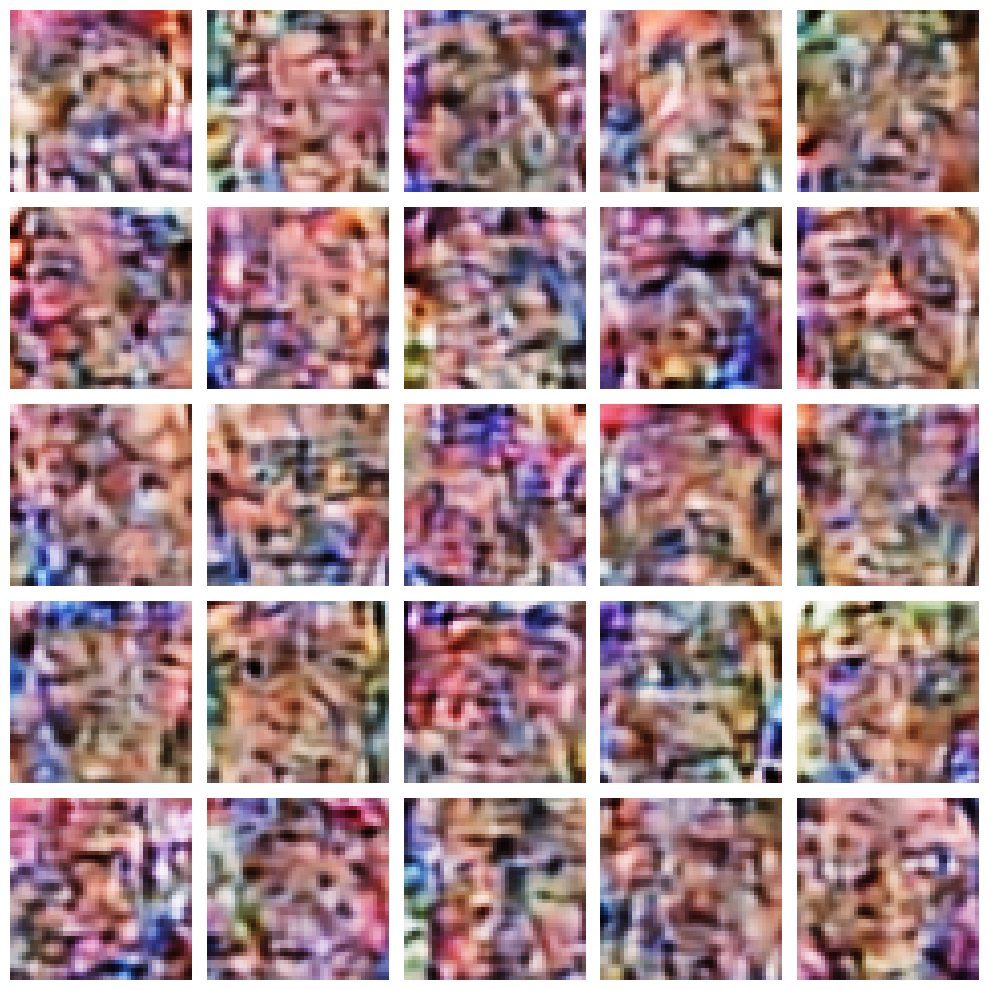

In [208]:
# сгенерируем 25 рандомных векторов размера latent_space
z = np.random.randn(25, dim_code)
z = torch.from_numpy(z).float().to(device) 

autoencoder.eval()
with torch.no_grad():
    output = autoencoder.decoder(z).view(-1, 3, 45, 45)

# рисуем
fig, axes = plt.subplots(5, 5, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    img = output[i].cpu().permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.axis('off')
plt.tight_layout(); 

plt.show()

In [209]:
# посмотрим на распределение как в подсказке
autoencoder.eval()
all_z = []
with torch.no_grad():
    for X_batch, _ in train_loader:
        X_batch = X_batch.to(device)
        _, z = autoencoder(X_batch) 
        all_z.append(z)
all_z = torch.cat(all_z)
print(all_z.shape)


torch.Size([11828, 256])


In [210]:
mu  = all_z.mean(dim=0)
sigma = all_z.std(dim=0) 

print("mu range: ", mu.min().item(),    mu.max().item(), mu.mean().item())
print("sigma range: ", sigma.min().item(), sigma.max().item(), sigma.mean().item())

mu range:  -2.9811015129089355 2.8418121337890625 -0.0006721229292452335
sigma range:  0.33431199193000793 2.072387456893921 0.5593471527099609


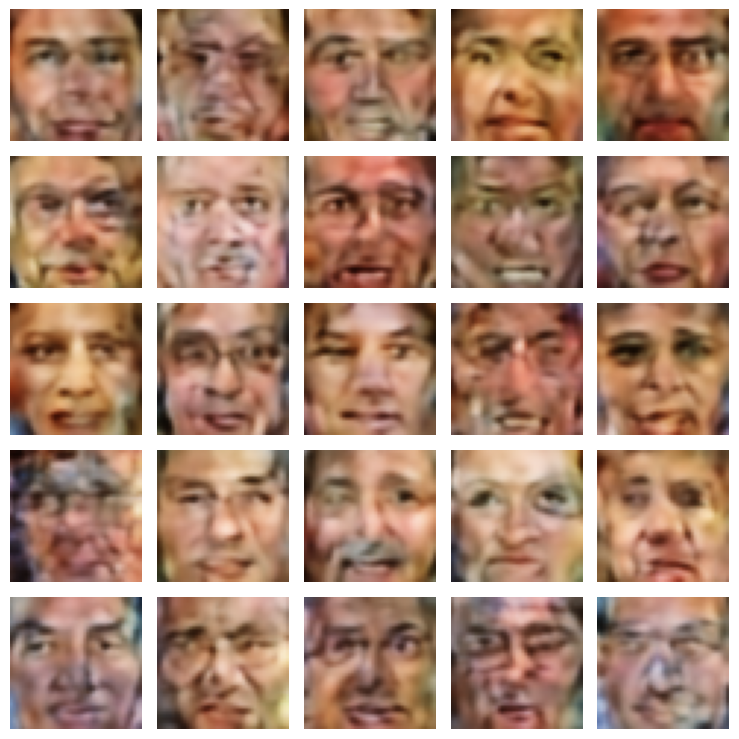

In [211]:
# сэмплинг из подогнанного распределения

z_std = torch.randn(25, dim_code, device=device)
z = z_std * sigma + mu 

# Если сгенерировать на основе ковариации то получится гораздо лучше 
# (будет учтена взаимосвязь между компонентами вектора), 
# но я не буду это использовать т.к. не понимаю механику этого способа
# cov = torch.cov(all_z.T)
# dist = torch.distributions.MultivariateNormal(mu, covariance_matrix=cov)
# z = dist.sample((25,)).to(device)


with torch.no_grad():
    output = autoencoder.decoder(z).cpu()

fig, axes = plt.subplots(5, 5, figsize=(7.5, 7.5))
for i, ax in enumerate(axes.flat):
    ax.imshow(output[i].permute(1, 2, 0).numpy())
    ax.axis('off')
plt.tight_layout(); plt.show()

## 1.5 Time to make fun! (3 балла)

Давайте научимся пририсовывать людям улыбки =)

<img src="https://i.imgur.com/tOE9rDK.png" alt="linear" width="700" height="400">

План такой:

1. Нужно выделить "вектор улыбки": для этого нужно из выборки изображений найти несколько (~15) людей с улыбками и столько же без.

Найти людей с улыбками вам поможет файл с атрибутами, скачанный вместе с картинками. В нем указаны имена изображений и присутствубщие атрибуты (улыбки, очки и прочее интересное).

2. Вычислить латентный вектор для всех улыбающихся людей (прогнать их через encoder) и то же для всех грустненьких.

3. Вычислить, собственно, вектор улыбки -- посчитать разность между средним латентным вектором улыбающихся людей и средним латентным вектором грустных людей.

4. А теперь приделаем улыбку грустному человеку: добавим полученный в пункте 3 вектор к латентному вектору грустного человека и прогоним полученный вектор через decoder. Получим того же человека, но уже не грустненького!

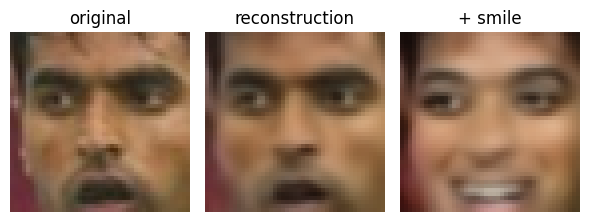

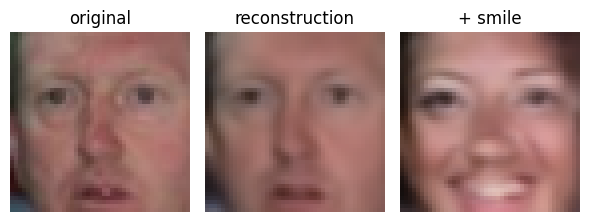

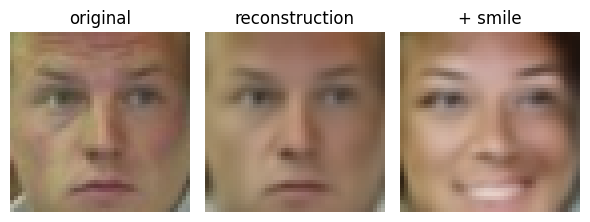

In [212]:
sorted_positions = np.argsort(attrs_train['Smiling'].values)

sad_indices   = sorted_positions[:15]
smile_indices = sorted_positions[-15:]


autoencoder.eval()
with torch.no_grad():
    X_smile = X_train[smile_indices].to(device)
    X_sad   = X_train[sad_indices].to(device)
    _, z_smile = autoencoder(X_smile)
    _, z_sad   = autoencoder(X_sad)

smile_vector = z_smile.mean(dim=0) - z_sad.mean(dim=0)



def draw_smilized(index):
    # по индексу из самых грустных
    target_pos = sad_indices[index] 
    X_target = X_train[target_pos:target_pos+1].to(device)

    with torch.no_grad():
        _, z_target = autoencoder(X_target)
        rec_orig    = autoencoder.decoder(z_target).cpu()
        rec_smiled  = autoencoder.decoder(z_target + smile_vector).cpu()

    fig, axes = plt.subplots(1, 3, figsize=(6, 2.2))

    axes[0].imshow(X_train[target_pos].permute(1, 2, 0).numpy());
    axes[0].set_title('original')

    axes[1].imshow(rec_orig[0].permute(1, 2, 0).numpy())
    axes[1].set_title('reconstruction')

    axes[2].imshow(rec_smiled[0].permute(1, 2, 0).numpy())
    axes[2].set_title('+ smile')

    for ax in axes: ax.axis('off')
    plt.tight_layout(); plt.show()

draw_smilized(0)
draw_smilized(1)
draw_smilized(2)


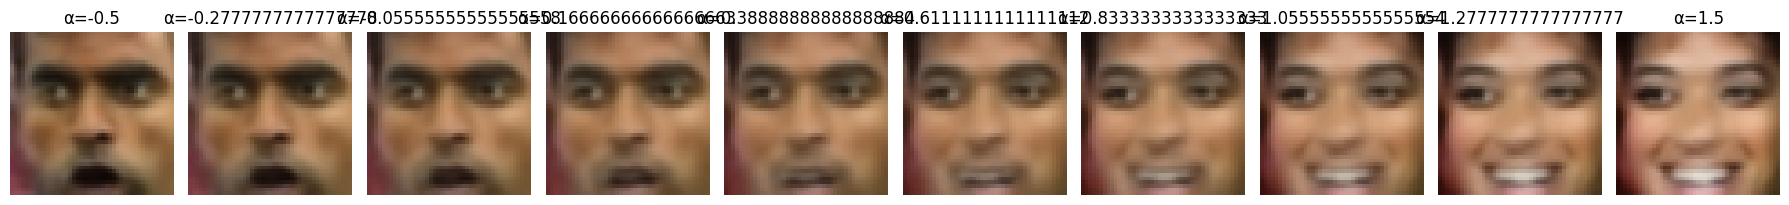

In [213]:
target_pos = sad_indices[0]
X_target = X_train[target_pos:target_pos+1].to(device)   # shape (1, 3, 45, 45)

autoencoder.eval()
with torch.no_grad():
    _, z_target = autoencoder(X_target)

alphas = np.linspace(-0.5, 1.5, 10)

fig, axes = plt.subplots(1, len(alphas), figsize=(len(alphas)*1.8, 2.2))
for ax, a in zip(axes, alphas):
    with torch.no_grad():
        img = autoencoder.decoder(z_target + a * smile_vector).cpu()
    ax.imshow(img[0].permute(1, 2, 0).numpy())
    ax.set_title(f'α={a}')
    ax.axis('off')
plt.tight_layout(); plt.show()


Вуаля! Вы восхитительны!

Теперь вы можете пририсовывать людям не только улыбки, но и много чего другого -- закрывать/открывать глаза, пририсовывать очки... В общем, все, на что хватит фантазии и на что есть атрибуты в `attrs`:)

# Часть 2: Variational Autoencoder (10 баллов)

Займемся обучением вариационных автоэнкодеров — проапгрейженной версии AE. Обучать будем на датасете MNIST, содержащем написанные от руки цифры от 0 до 9

In [214]:
from torchvision import datasets, transforms
batch_size = 32
# MNIST Dataset
train_dataset = datasets.MNIST(root='./mnist_data/', train=True, transform=transforms.ToTensor(), download=True)
test_dataset = datasets.MNIST(root='./mnist_data/', train=False, transform=transforms.ToTensor(), download=False)

# Data Loader (Input Pipeline)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

## 2.1 Архитектура модели и обучение (2 балла)

Реализуем VAE. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Рекомендуем пользоваться более сложными моделями, чем та, что была на семинаре:) Экспериментируйте!

In [215]:
dim_code = 64

In [216]:
class VAE(nn.Module):
    def __init__(self, dim_code):
        super().__init__()
        # <определите архитектуры encoder и decoder>

        # Вход (1, 28, 28)
        self.encoder = nn.Sequential(

            nn.Conv2d(1, 32, 3, stride = 2, padding = 1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride = 2, padding = 1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride = 2, padding = 1),
            nn.ReLU(),

            nn.Flatten(),
        )
        self.fc_mu       = nn.Linear(128*4*4, dim_code)
        self.fc_logsigma = nn.Linear(128*4*4, dim_code)

        self.decoder = nn.Sequential(
            nn.Linear(dim_code, 128*4*4),
            nn.ReLU(),
            nn.Unflatten(1, (128, 4, 4)),
            nn.ConvTranspose2d(128, 64, 3, stride = 2, padding = 1, output_padding=0),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 3, stride = 2, padding = 1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 3, stride = 2, padding = 1, output_padding=1),
            nn.Sigmoid()
        )

    def gaussian_sampler(self, mu, logsigma):
        if self.training:
            std = torch.exp(0.5 * logsigma)
            eps = torch.randn_like(std)
            return mu + eps * std
        else:
            # на инференсе возвращаем не случайный вектор из нормального распределения, а центральный -- mu.
            # на инференсе выход автоэнкодера должен быть детерминирован.
            return mu

    def decode(self, z):
        reconstruction = self.decoder(z)
        return reconstruction

    def forward(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logsigma = self.fc_logsigma(h)
        z = self.gaussian_sampler(mu, logsigma)
        reconstruction = self.decoder(z)
        return mu, logsigma, reconstruction

In [217]:
vae = VAE(dim_code=dim_code)
mu, logsigma, rec = vae(torch.randn(2, 1, 28, 28))
print(mu.shape, logsigma.shape, rec.shape)

torch.Size([2, 64]) torch.Size([2, 64]) torch.Size([2, 1, 28, 28])


Определим лосс и его компоненты для VAE:

Надеюсь, вы уже прочитали материал в towardsdatascience (или еще где-то) про VAE и знаете, что лосс у VAE состоит из двух частей: KL и log-likelihood.

Общий лосс будет выглядеть так:

$$\mathcal{L} = -D_{KL}(q_{\phi}(z|x)||p(z)) + \log p_{\theta}(x|z)$$

Формула для KL-дивергенции:

$$D_{KL} = -\frac{1}{2}\sum_{i=1}^{dimZ}(1+log(\sigma_i^2)-\mu_i^2-\sigma_i^2)$$

В качестве log-likelihood возьмем привычную нам кросс-энтропию.

In [218]:
def KL_divergence(mu, logsigma):
    """
    часть функции потерь, которая отвечает за "близость" латентных представлений разных людей
    """
    loss = -0.5 * torch.sum(1 + logsigma - mu.pow(2) - logsigma.exp())
    return loss

def log_likelihood(x, reconstruction):
    """
    часть функции потерь, которая отвечает за качество реконструкции (как mse в обычном autoencoder)
    """
    loss = nn.BCELoss(reduction='sum')
    return loss(reconstruction, x)

def loss_vae(x, mu, logsigma, reconstruction):
    return log_likelihood(x, reconstruction) + KL_divergence(mu, logsigma)

И обучим модель:

In [219]:
import gc
# почистим память перед обучением
autoencoder = None
gc.collect()
torch.mps.empty_cache()  

print(f"Allocated: {torch.mps.current_allocated_memory() / 1024**3:.2f} GiB")
print(f"Driver: {torch.mps.driver_allocated_memory() / 1024**3:.2f} GiB") 

criterion = loss_vae

autoencoder = VAE(dim_code=dim_code).to(device)

optimizer = torch.optim.Adam(autoencoder.parameters(), lr=3*1e-4)


Allocated: 0.06 GiB
Driver: 0.15 GiB


In [220]:
def show_reconstructions_mnist(model, loader, n, device):
    model.eval()
    with torch.no_grad():
        X, _ = next(iter(loader))
        X = X[:n].to(device)
        _, _, rec = model(X)
        
    fig, axes = plt.subplots(2, n, figsize=(n*1.5, 3))

    for i in range(n):

        axes[0, i].imshow(X[i].cpu().squeeze(), cmap='gray')
        axes[0, i].axis('off')

        axes[1, i].imshow(rec[i].cpu().squeeze(), cmap='gray')
        axes[1, i].axis('off')

    plt.tight_layout(); plt.show()


In [221]:
from tqdm.notebook import tqdm

train_losses = []
val_losses = []
n_epochs = 60
best_val = float('inf')

for epoch in tqdm(range(n_epochs), desc="Epochs"):
    autoencoder.train()
    train_loss = 0
    for X_batch, _ in tqdm(train_loader, desc=f"epoch {epoch+1}", leave=False):
        X_batch = X_batch.to(device)
        optimizer.zero_grad()
        mu, logsigma, reconstruction = autoencoder(X_batch)
        loss = criterion(X_batch, mu, logsigma, reconstruction)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)
    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)

    autoencoder.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, _ in test_loader:
            X_batch = X_batch.to(device)
            mu, logsigma, reconstruction = autoencoder(X_batch)
            loss = criterion(X_batch, mu, logsigma, reconstruction)
            val_loss += loss.item() * X_batch.size(0)
    val_loss /= len(test_loader.dataset)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{n_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    if val_loss < best_val:
        best_val = val_loss
        torch.save(autoencoder.state_dict(), 'best_vae.pt')

    #
    # if (epoch + 1) % 10 == 0:
        # show_reconstructions_mnist(autoencoder, test_loader, n=4, device=device)

Epochs:   0%|          | 0/60 [00:00<?, ?it/s]

epoch 1:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 1/60, Train Loss: 5016.0214, Val Loss: 3629.5747


epoch 2:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 2/60, Train Loss: 3768.7618, Val Loss: 3294.1041


...

Epoch 58/60, Train Loss: 3065.3733, Val Loss: 2817.1824


epoch 59:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 59/60, Train Loss: 3063.2743, Val Loss: 2805.5556


epoch 60:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 60/60, Train Loss: 3061.7414, Val Loss: 2805.7381


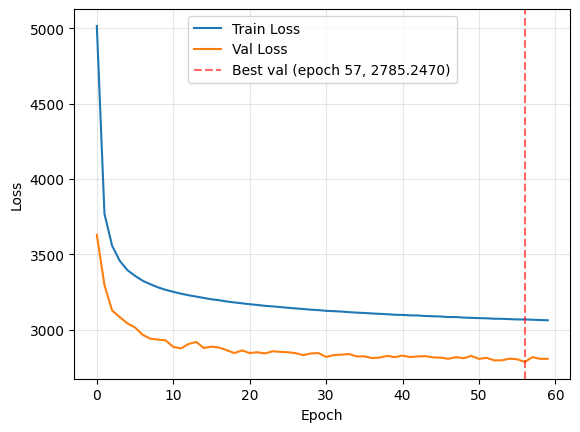

In [222]:
import numpy as np

best_epoch = int(np.argmin(val_losses))

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.axvline(best_epoch, color='red', linestyle='--', alpha=0.6,
            label=f'Best val (epoch {best_epoch+1}, {val_losses[best_epoch]:.4f})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Давайте посмотрим, как наш тренированный VAE кодирует и восстанавливает картинки:

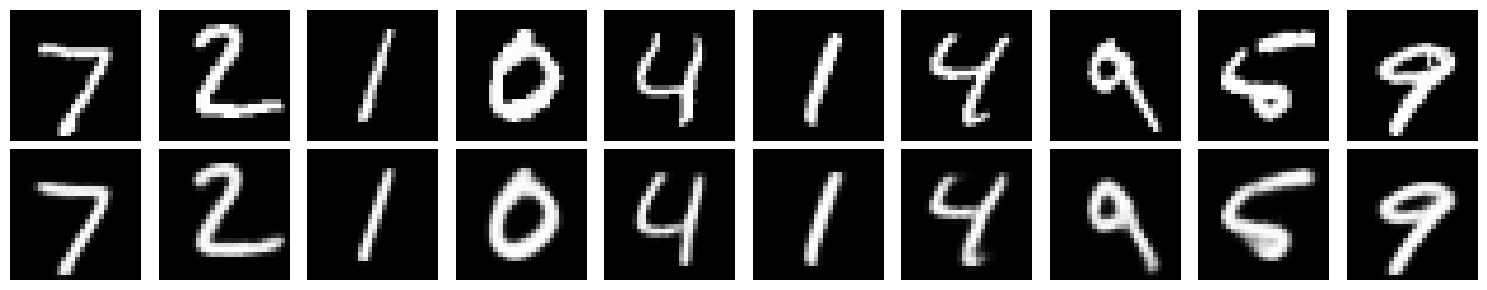

In [223]:
autoencoder.load_state_dict(torch.load('best_vae.pt'))
autoencoder.eval()

show_reconstructions_mnist(autoencoder, test_loader, n=10, device=device)

Давайте попробуем проделать для VAE то же, что и с обычным автоэнкодером -- подсунуть decoder'у из VAE случайные векторы из нормального распределения и посмотреть, какие картинки получаются:

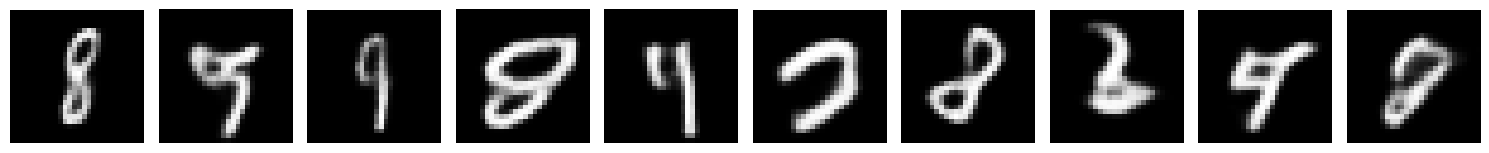

In [224]:
# вспомните про замечание из этого же пункта обычного AE про распределение латентных переменных
n_samples = 10
z = torch.randn(n_samples, dim_code, device=device)
with torch.no_grad():
    output = autoencoder.decode(z).cpu().numpy()

# выведите тут полученные картинки
plt.figure(figsize=(15, 3))
for i in range(n_samples):
    plt.subplot(1, n_samples, i+1)
    plt.imshow(output[i, 0], cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.show()

## 2.2. Latent Representation (2 балла)

Давайте посмотрим, как латентные векторы картинок лиц выглядят в пространстве.
Ваша задача -- изобразить латентные векторы картинок точками в двумерном просторанстве.

Это позволит оценить, насколько плотно распределены латентные векторы изображений цифр в пространстве.

Плюс давайте сделаем такую вещь: покрасим точки, которые соответствуют картинкам каждой цифры, в свой отдельный цвет

Подсказка: красить -- это просто =) У plt.scatter есть параметр c (color), см. в документации.


Итак, план:
1. Получить латентные представления картинок тестового датасета
2. С помощтю `TSNE` (есть в `sklearn`) сжать эти представления до размерности 2 (чтобы можно было их визуализировать точками в пространстве)
3. Визуализировать полученные двумерные представления с помощью `matplotlib.scatter`, покрасить разными цветами точки, соответствующие картинкам разных цифр.

/var/folders/3k/yz_mzz_938lgc9w3r_6v4hxc0000gn/T/ipykernel_5140/2791959308.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='digit', markerscale=2)


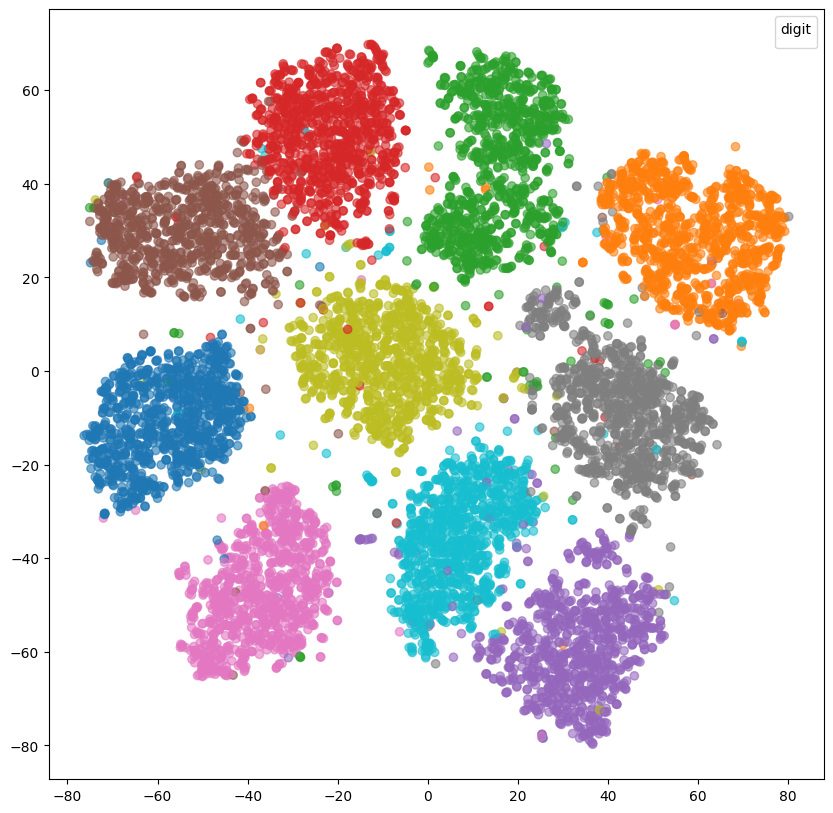

In [225]:
#<ваш код получения латентных представлений, применения TSNE и визуализации>

from sklearn.manifold import TSNE

autoencoder.eval()
all_latents, all_labels = [], []
with torch.no_grad():
    for X_batch, labels in test_loader:
        X_batch = X_batch.to(device)
        mu, _, _ = autoencoder(X_batch) 
        all_latents.append(mu.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

latents = np.concatenate(all_latents, axis=0)
labels = np.concatenate(all_labels, axis=0)

latents_2d = TSNE(n_components=2, random_state=RANDOM_SEED).fit_transform(latents)

plt.figure(figsize=(10, 10))
scatter = plt.scatter(
    latents_2d[:, 0],
    latents_2d[:, 1],
    c=labels,
    cmap='tab10',
    alpha=0.6
)
plt.legend(title='digit', markerscale=2)
plt.show()

Что вы думаете о виде латентного представления?

Думаю, что это великолепно, и я великолепен

__Congrats v2.0!__

## 2.3. Conditional VAE (6 баллов)


Мы уже научились обучать обычный AE на датасете картинок и получать новые картинки, используя генерацию шума и декодер.
Давайте теперь допустим, что мы обучили AE на датасете MNIST и теперь хотим генерировать новые картинки с числами с помощью декодера (как выше мы генерили рандомные лица).
И вот нам понадобилось сгенерировать цифру 8, и мы подставляем разные варианты шума, но восьмерка никак не генерится:(

Хотелось бы добавить к нашему AE функцию "выдай мне рандомное число из вот этого вот класса", где классов десять (цифры от 0 до 9 образуют десять классов).  Conditional AE — так называется вид автоэнкодера, который предоставляет такую возможность. Ну, название "conditional" уже говорит само за себя.

И в этой части задания мы научимся такие обучать.

### Архитектура

На картинке ниже представлена архитектура простого Conditional VAE.

По сути, единственное отличие от обычного -- это то, что мы вместе с картинкой в первом слое энкодера и декодера передаем еще информацию о классе картинки.

То есть, в первый (входной) слой энкодера подается конкатенация картинки и информации о классе (например, вектора из девяти нулей и одной единицы). В первый слой декодера подается конкатенация латентного вектора и информации о классе.


![alt text](https://sun9-63.userapi.com/impg/Mh1akf7mfpNoprrSWsPOouazSmTPMazYYF49Tw/djoHNw_9KVA.jpg?size=1175x642&quality=96&sign=e88baec5f9bb91c8443fba31dcf0a4df&type=album)

![alt text](https://sun9-73.userapi.com/impg/UDuloLNKhzTBYAKewgxke5-YPsAKyGOqA-qCRg/MnyCavJidxM.jpg?size=1229x651&quality=96&sign=f2d21bfacc1c5755b76868dc4cfef39c&type=album)



На всякий случай: это VAE, то есть, latent у него все еще состоит из mu и sigma

Таким образом, при генерации новой рандомной картинки мы должны будем передать декодеру сконкатенированные латентный вектор и класс картинки.

P.S. Также можно передавать класс картинки не только в первый слой, но и в каждый слой сети. То есть на каждом слое конкатенировать выход из предыдущего слоя и информацию о классе.

In [226]:
import torch.nn.functional as F

class CVAE(nn.Module):
    def __init__(self, dim_code, n_classes):
        # <определите архитектуры encoder и decoder
        # помните, у encoder должны быть два "хвоста",
        # т.е. encoder должен кодировать картинку в 2 переменные -- mu и logsigma>
        super().__init__()
        self.n_classes = n_classes

        # Вход (1 + n_classes, 28, 28)
        self.encoder = nn.Sequential(

            nn.Conv2d(1 + n_classes, 32, 3, stride = 2, padding = 1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride = 2, padding = 1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride = 2, padding = 1),
            nn.ReLU(),

            nn.Flatten(),
        )
        self.fc_mu       = nn.Linear(128*4*4, dim_code)
        self.fc_logsigma = nn.Linear(128*4*4, dim_code)

        self.decoder = nn.Sequential(
            nn.Linear(dim_code + n_classes, 128*4*4),
            nn.ReLU(),
            nn.Unflatten(1, (128, 4, 4)),
            nn.ConvTranspose2d(128, 64, 3, stride = 2, padding = 1, output_padding=0),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 3, stride = 2, padding = 1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 3, stride = 2, padding = 1, output_padding=1),
            nn.Sigmoid()
        )

    def encode(self, x, y_onehot):
        # <реализуйте forward проход энкодера
        # в качестве возвращаемых переменных -- mu, logsigma и класс картинки>
        H, W = x.shape[2], x.shape[3]
        y_map = y_onehot.unsqueeze(-1).unsqueeze(-1).expand(-1, -1, H, W)
        h = self.encoder(torch.cat([x, y_map], dim=1))
        return self.fc_mu(h), self.fc_logsigma(h), y_onehot


    def gaussian_sampler(self, mu, logsigma):
        if self.training:
            # засемплируйте латентный вектор из нормального распределения с параметрами mu и sigma
            std = torch.exp(0.5 * logsigma)
            eps = torch.randn_like(std)
            return mu + eps * std
        else:
            # на инференсе возвращаем не случайный вектор из нормального распределения, а центральный -- mu.
            # на инференсе выход автоэнкодера должен быть детерминирован.
            return mu

    def decode(self, z, y_onehot):
        # реализуйте forward проход декодера
        # в качестве возвращаемой переменной -- reconstruction
        z_cat = torch.cat([z, y_onehot], dim=1)
        reconstruction = self.decoder(z_cat)
        return reconstruction

    def forward(self, x, y):
        # используя encode и decode, реализуйте forward проход автоэнкодера
        # в качестве ваозвращаемых переменных -- mu, logsigma и reconstruction
        y_onehot = F.one_hot(y, num_classes=self.n_classes).float()
        mu, logsigma, _ = self.encode(x, y_onehot)
        z = self.gaussian_sampler(mu, logsigma)
        reconstruction = self.decode(z, y_onehot)
        return mu, logsigma, reconstruction
    

In [227]:
cvae = CVAE(dim_code=dim_code, n_classes=10)
x = torch.randn(2, 1, 28, 28)
y = torch.tensor([3, 7])
mu, logsigma, rec = cvae(x, y)
print(mu.shape, logsigma.shape, rec.shape)

torch.Size([2, 64]) torch.Size([2, 64]) torch.Size([2, 1, 28, 28])


In [228]:
import gc
# почистим память перед обучением
autoencoder = None
gc.collect()
torch.mps.empty_cache()  

print(f"Allocated: {torch.mps.current_allocated_memory() / 1024**3:.2f} GiB")
print(f"Driver: {torch.mps.driver_allocated_memory() / 1024**3:.2f} GiB") 

criterion = loss_vae

autoencoder = CVAE(dim_code=dim_code, n_classes=10).to(device)

optimizer = torch.optim.Adam(autoencoder.parameters(), lr=3*1e-4)


from tqdm.notebook import tqdm

train_losses = []
val_losses = []
n_epochs = 60
best_val = float('inf')

for epoch in tqdm(range(n_epochs), desc="Epochs"):
    autoencoder.train()
    train_loss = 0
    for X_batch, y_batch in tqdm(train_loader, desc=f"epoch {epoch+1}", leave=False):
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        mu, logsigma, reconstruction = autoencoder(X_batch, y_batch)
        loss = criterion(X_batch, mu, logsigma, reconstruction)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)
    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)

    autoencoder.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            mu, logsigma, reconstruction = autoencoder(X_batch, y_batch)
            loss = criterion(X_batch, mu, logsigma, reconstruction)
            val_loss += loss.item() * X_batch.size(0)
    val_loss /= len(test_loader.dataset)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{n_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    if val_loss < best_val:
        best_val = val_loss
        torch.save(autoencoder.state_dict(), 'best_vae.pt')


Allocated: 0.03 GiB
Driver: 0.07 GiB


Epochs:   0%|          | 0/60 [00:00<?, ?it/s]

epoch 1:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 1/60, Train Loss: 5232.5300, Val Loss: 3737.6742


epoch 2:   0%|          | 0/1875 [00:00<?, ?it/s]

...

Epoch 58/60, Train Loss: 2898.6751, Val Loss: 2668.4675


epoch 59:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 59/60, Train Loss: 2897.0687, Val Loss: 2678.3600


epoch 60:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 60/60, Train Loss: 2894.1993, Val Loss: 2655.2914


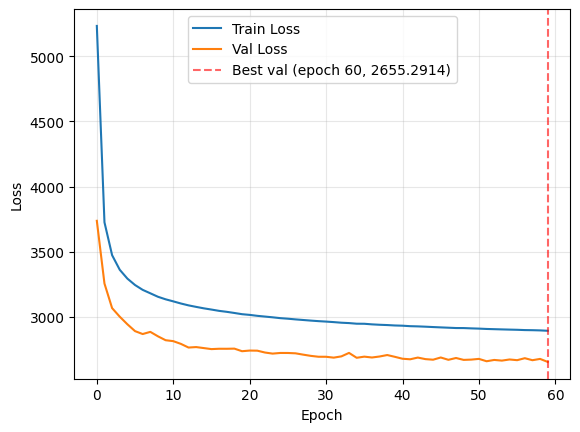

In [229]:
import numpy as np

best_epoch = int(np.argmin(val_losses))

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.axvline(best_epoch, color='red', linestyle='--', alpha=0.6,
            label=f'Best val (epoch {best_epoch+1}, {val_losses[best_epoch]:.4f})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


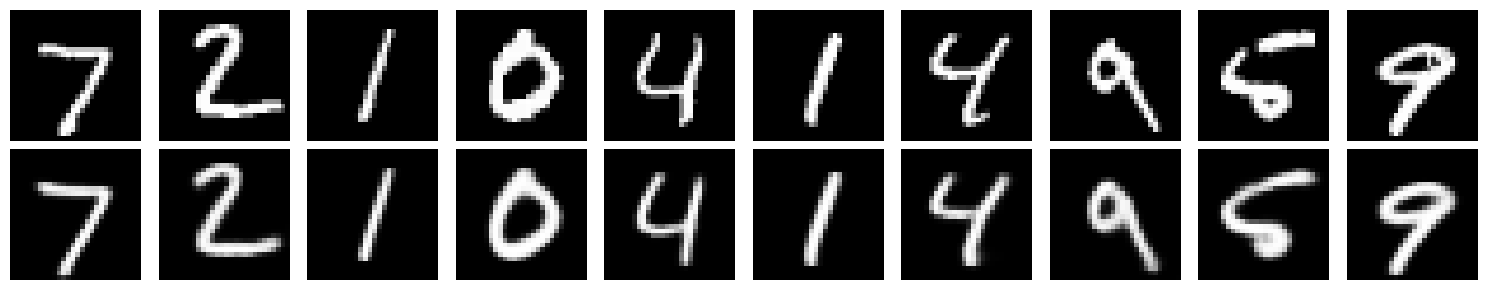

In [230]:
def show_reconstructions_mnist_cvae(model, loader, n, device):
    model.eval()
    with torch.no_grad():
        X, y = next(iter(loader))
        X = X[:n].to(device)
        y = y[:n].to(device) 
        _, _, rec = model(X, y)

    fig, axes = plt.subplots(2, n, figsize=(n*1.5, 3))
    for i in range(n):
        axes[0, i].imshow(X[i].cpu().squeeze(), cmap='gray');   axes[0, i].axis('off')
        axes[1, i].imshow(rec[i].cpu().squeeze(), cmap='gray'); axes[1, i].axis('off')
    plt.tight_layout(); plt.show()

show_reconstructions_mnist_cvae(autoencoder, test_loader, n=10, device=device)


### Sampling


Тут мы будем сэмплировать из CVAE. Это прикольнее, чем сэмплировать из простого AE/VAE: тут можно взять один и тот же латентный вектор и попросить CVAE восстановить из него картинки разных классов!
Для MNIST вы можете попросить CVAE восстановить из одного латентного вектора, например, картинки цифры 5 и 7.

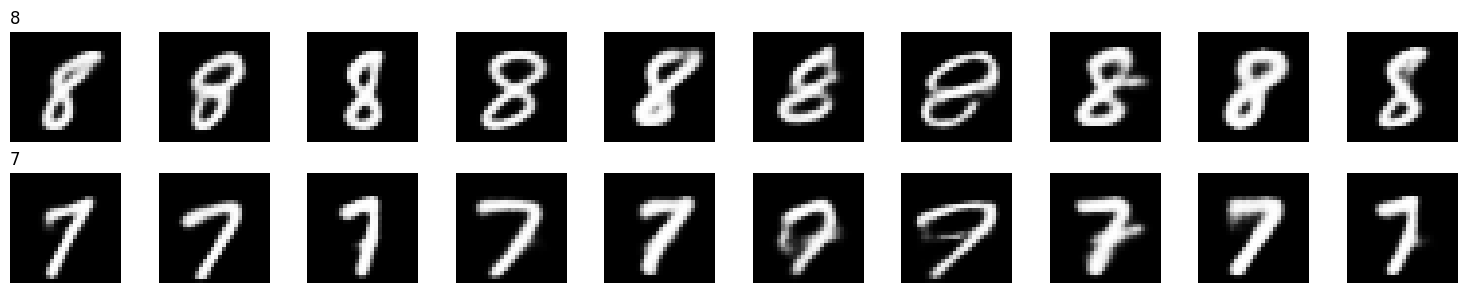

In [231]:
n_samples = 10
target_digit_8 = 8
target_digit_7 = 7

z = torch.randn(n_samples, dim_code, device=device)

def make_onehot(digit, n):
    y = torch.full((n,), digit, dtype=torch.long, device=device)
    return F.one_hot(y, num_classes=10).float()


y_onehot_8 = make_onehot(8, n_samples)
y_onehot_7 = make_onehot(7, n_samples)

with torch.no_grad():
    output_8 = autoencoder.decode(z, y_onehot_8).cpu().numpy()
    output_7 = autoencoder.decode(z, y_onehot_7).cpu().numpy()


ig, axes = plt.subplots(2, n_samples, figsize=(15, 3))
for i in range(n_samples):
    axes[0, i].imshow(output_8[i, 0], cmap='gray')
    axes[0, i].axis('off')

    axes[1, i].imshow(output_7[i, 0], cmap='gray')
    axes[1, i].axis('off')
    
axes[0, 0].set_title('8', loc='left'); axes[1, 0].set_title('7', loc='left')
plt.tight_layout(); plt.show()

Splendid! Вы великолепны!


### Latent Representations

Давайте посмотрим, как выглядит латентное пространство картинок в CVAE и сравним с картинкой для VAE =)

Опять же, нужно покрасить точки в разные цвета в зависимости от класса.

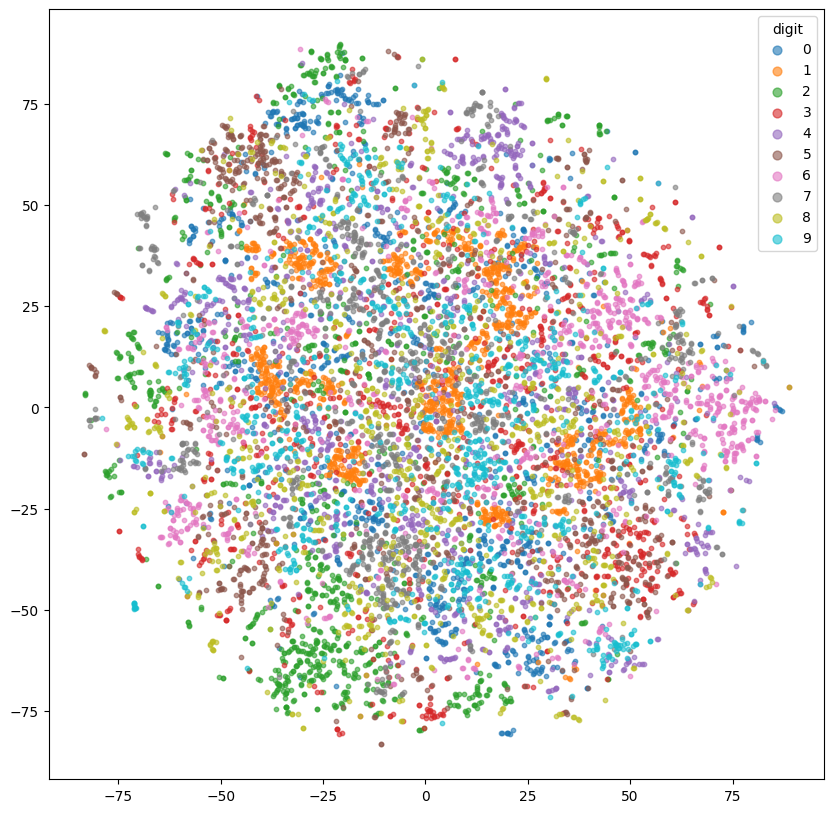

In [232]:
# <ваш код получения латентных представлений, применения TSNE и визуализации>

from sklearn.manifold import TSNE

autoencoder.eval()
all_latents, all_labels = [], []
with torch.no_grad():
    for X_batch, labels in test_loader:
        X_batch = X_batch.to(device)
        labels_dev = labels.to(device)

        mu, _, _ = autoencoder(X_batch, labels_dev) 
        
        all_latents.append(mu.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

latents = np.concatenate(all_latents, axis=0)
labels = np.concatenate(all_labels, axis=0)

latents_2d = TSNE(n_components=2, random_state=RANDOM_SEED).fit_transform(latents)

plt.figure(figsize=(10, 10))
for c in range(10):
    mask = labels == c
    plt.scatter(latents_2d[mask, 0], latents_2d[mask, 1],
                label=str(c), alpha=0.6, s=10)
plt.legend(title='digit', markerscale=2)
plt.show()

Что вы думаете насчет этой картинки? Отличается от картинки для VAE?

Отличается, потому что перестало группироваться, т.к. модель не кодирует в латенте классификацию. Но по-прежнему великолепно! И я тоже великолепен. Возьмите меня на работу.

# BONUS 1: Denoising (2 балла)



У автоэнкодеров, кроме сжатия и генерации изображений, есть другие практические применения. Про одно из них эта бонусная часть задания.

Автоэнкодеры могут быть использованы для избавления от шума на фотографиях (denoising). Для этого их нужно обучить специальным образом: input картинка будет зашумленной, а выдавать автоэнкодер должен будет картинку без шума.
То есть, loss-функция AE останется той же (MSE между реальной картинкой и выданной), а на вход автоэнкодеру будет подаваться зашумленная картинка.

<a href="https://ibb.co/YbRJ1nZ"><img src="https://i.ibb.co/0QD164t/Screen-Shot-2020-06-04-at-4-49-50-PM.png" alt="Screen-Shot-2020-06-04-at-4-49-50-PM" border="0"></a>

Для этого нужно взять ваш любимый датасет (датасет лиц из первой части этого задания или любой другой) и сделать копию этого датасета с шумом.

В питоне шум можно добавить так:

In [233]:
noise_factor = 0.5
#X_noisy = X + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X.shape)


X_train, X_val, attrs_train, attrs_val = train_test_split(
    images,
    attrs,
    train_size=0.9, shuffle=False, random_state=RANDOM_SEED)


# uint8 → float32 в диапазоне [0, 1]
X_train = X_train.astype('float32') / 255.0
X_val   = X_val.astype('float32') / 255.0

# X_train_noisy = X_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_train.shape)
# X_val_noisy   = X_val + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_val.shape)

# (N, H, W, C) → (N, C, H, W) — PyTorch формат каналов
X_train = torch.from_numpy(X_train).permute(0, 3, 1, 2)
X_val   = torch.from_numpy(X_val).permute(0, 3, 1, 2)


def make_loader(X, attrs_df, batch_size=32, shuffle=False):
    attrs_t = torch.from_numpy(attrs_df.astype('float32').values)
    ds = TensorDataset(X, attrs_t)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


train_loader = make_loader(X_train, attrs_train, shuffle=True)
val_loader   = make_loader(X_val, attrs_val, shuffle=False)

In [234]:
# <тут ваш код обучения автоэнкодера на зашумленных картинках. Не забудьте разбить на train/test!>

import gc
# почистим память перед обучением
gc.collect()
torch.mps.empty_cache()  

print(f"Allocated: {torch.mps.current_allocated_memory() / 1024**3:.2f} GiB")
print(f"Driver: {torch.mps.driver_allocated_memory() / 1024**3:.2f} GiB") 

dim_code = 256
criterion = nn.MSELoss()
autoencoder = Autoencoder(dim_code=dim_code).to(device)
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)

# Добавим шум в процессе обучения через noise_factor=noise_factor

train_losses, val_losses = train_all(
    autoencoder, 
    train_loader, 
    val_loader, 
    n_epochs=n_epochs,
    noise_factor=noise_factor,
    save_path='best_ae_noisy.pt',
    verbose=False
)

Allocated: 0.03 GiB
Driver: 0.07 GiB


Epochs:   0%|          | 0/60 [00:00<?, ?it/s]

epoch 1:   0%|          | 0/370 [00:00<?, ?it/s]

Epoch 1/60, Train Loss: 0.0189, Val Loss: 0.0097


epoch 2:   0%|          | 0/370 [00:00<?, ?it/s]

...

Epoch 58/60, Train Loss: 0.0041, Val Loss: 0.0046


epoch 59:   0%|          | 0/370 [00:00<?, ?it/s]

Epoch 59/60, Train Loss: 0.0041, Val Loss: 0.0046


epoch 60:   0%|          | 0/370 [00:00<?, ?it/s]

Epoch 60/60, Train Loss: 0.0041, Val Loss: 0.0047


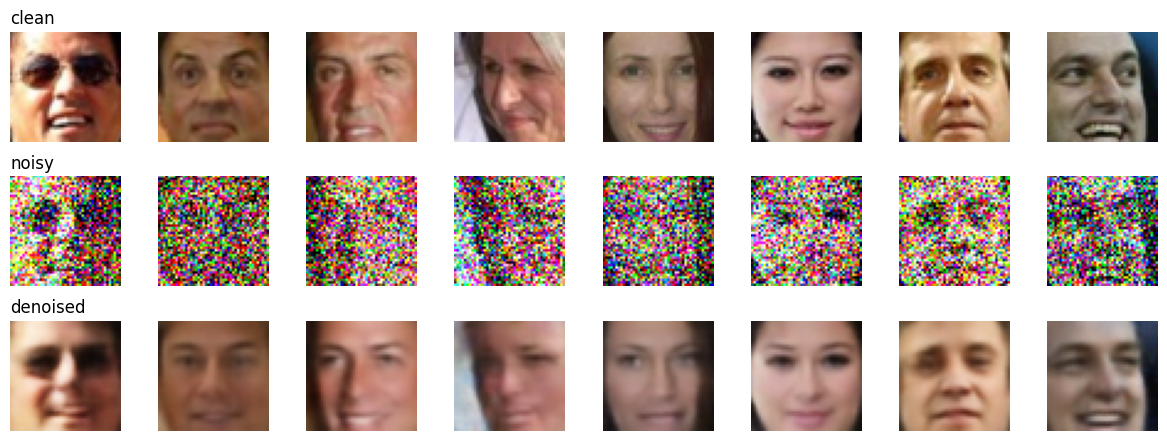

In [235]:
# <тут проверка, как AE убирает шум с тестовых картинок. Надеюсь, все получилось =)>

autoencoder.eval()

with torch.no_grad():
    X, _ = next(iter(val_loader))
    X = X[:8].to(device)

    # + шум
    X_noisy = add_noise(X, noise_factor)
    
    # картинку в шумом в автоэнкодер
    rec, _ = autoencoder(X_noisy)

# выведем результат

fig, axes = plt.subplots(3, 8, figsize=(12, 4.5))
for i in range(8):
    axes[0, i].imshow(X[i].cpu().permute(1, 2, 0).numpy());       axes[0, i].axis('off')
    axes[1, i].imshow(X_noisy[i].cpu().permute(1, 2, 0).numpy()); axes[1, i].axis('off')
    axes[2, i].imshow(rec[i].cpu().permute(1, 2, 0).numpy());     axes[2, i].axis('off')
axes[0, 0].set_title('clean',   loc='left')
axes[1, 0].set_title('noisy',   loc='left')
axes[2, 0].set_title('denoised',loc='left')
plt.tight_layout(); plt.show()


# BONUS 2: Image Retrieval (2 балла)



Давайте представим, что весь наш тренировочный датасет -- это большая база данных людей. И вот мы получили картинку лица какого-то человека с уличной камеры наблюдения (у нас это картинка из тестового датасета) и хотим понять, что это за человек. Что нам делать? Правильно -- берем наш VAE, кодируем картинку в латентное представление и ищем среди латентных представлений лиц нашей базы самые ближайшие!

План:

1. Получаем латентные представления всех лиц тренировочного датасета
2. Обучаем на них LSHForest `(sklearn.neighbors.LSHForest)`, например, с `n_estimators=50`
3. Берем картинку из тестового датасета, с помощью VAE получаем ее латентный вектор
4. Ищем с помощью обученного LSHForest ближайшие из латентных представлений тренировочной базы
5. Находим лица тренировочного датасета, которым соответствуют ближайшие латентные представления, визуализируем!

Немного кода вам в помощь: (feel free to delete everything and write your own)

In [236]:
# codes = <поучите латентные представления картинок из трейна>

autoencoder.eval()
codes = []
with torch.no_grad():
    for i in range(0, len(X_train), 256):
        batch = X_train[i:i+256].to(device)
        _, z = autoencoder(batch) 
        codes.append(z.cpu().numpy())
codes = np.concatenate(codes, axis=0)

In [237]:
# обучаем LSHForest - которого уже нет в библиотеке, поэтому обучаем NearestNeighbors 
from sklearn.neighbors import NearestNeighbors
nn_index = NearestNeighbors(n_neighbors=11, metric='euclidean').fit(codes)


In [238]:
def get_similar(image, n_neighbors=11):
    with torch.no_grad():
        _, code = autoencoder(image.unsqueeze(0).to(device))
    code = code.cpu().numpy()
    distances, idx = nn_index.kneighbors(code, n_neighbors=n_neighbors)
    return distances[0], X_train[idx[0]]

In [239]:
def show_similar(image):
    distances, neighbors = get_similar(image, n_neighbors=11)
    plt.figure(figsize=[10, 7])
    plt.subplot(3, 4, 1)
    plt.imshow(image.cpu().numpy().transpose(1, 2, 0))
    plt.title("Original"); plt.axis('off')
    for i in range(11):
        plt.subplot(3, 4, i + 2)
        plt.imshow(neighbors[i].numpy().transpose(1, 2, 0))
        plt.title(f"d={distances[i]:.2f}"); plt.axis('off')
    plt.tight_layout()
    plt.show()

# 1


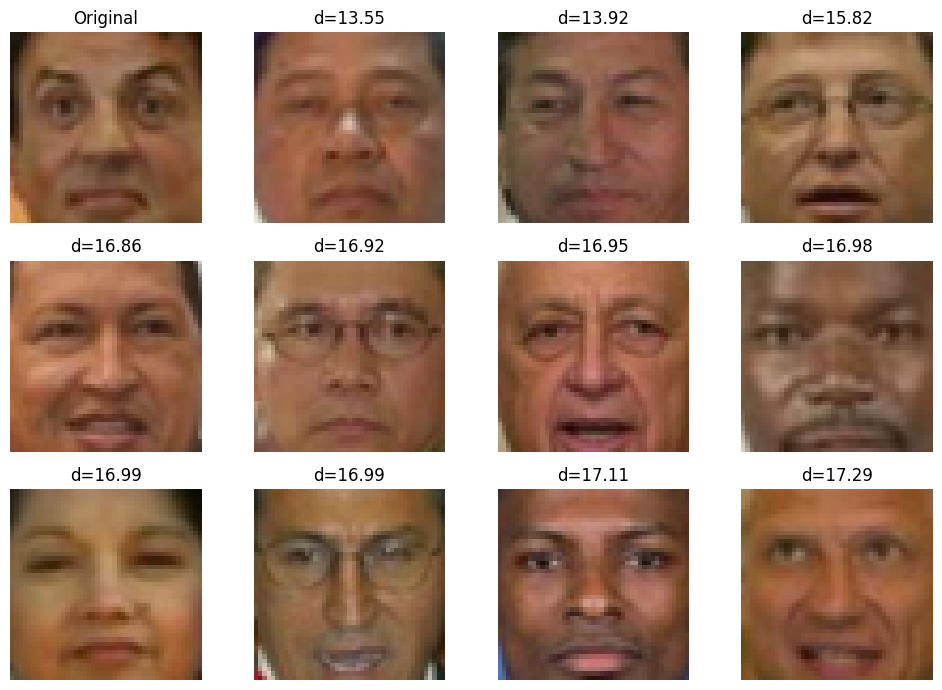

# 2


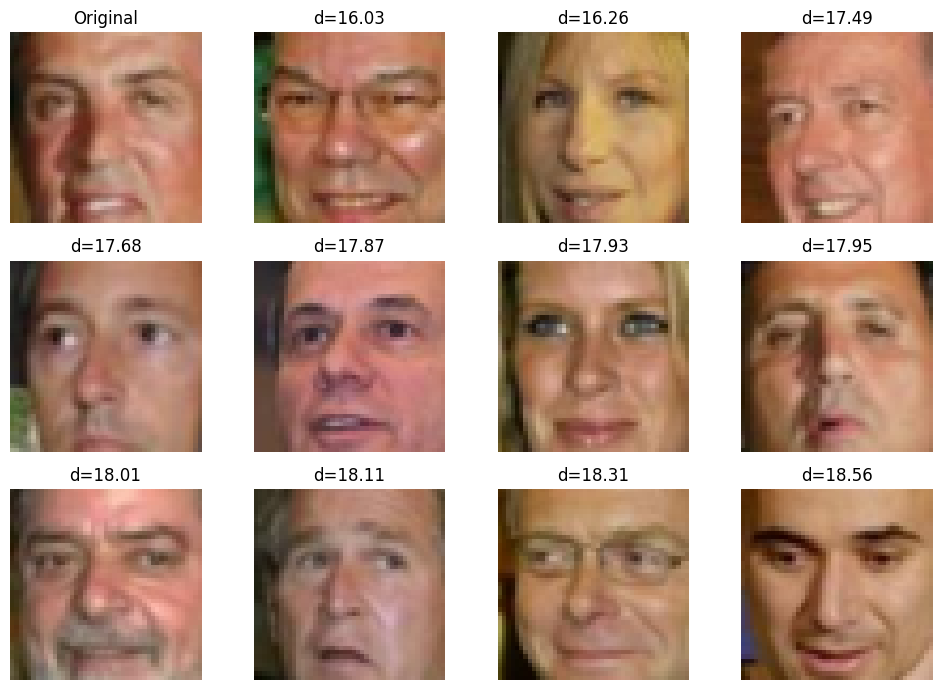

# 3


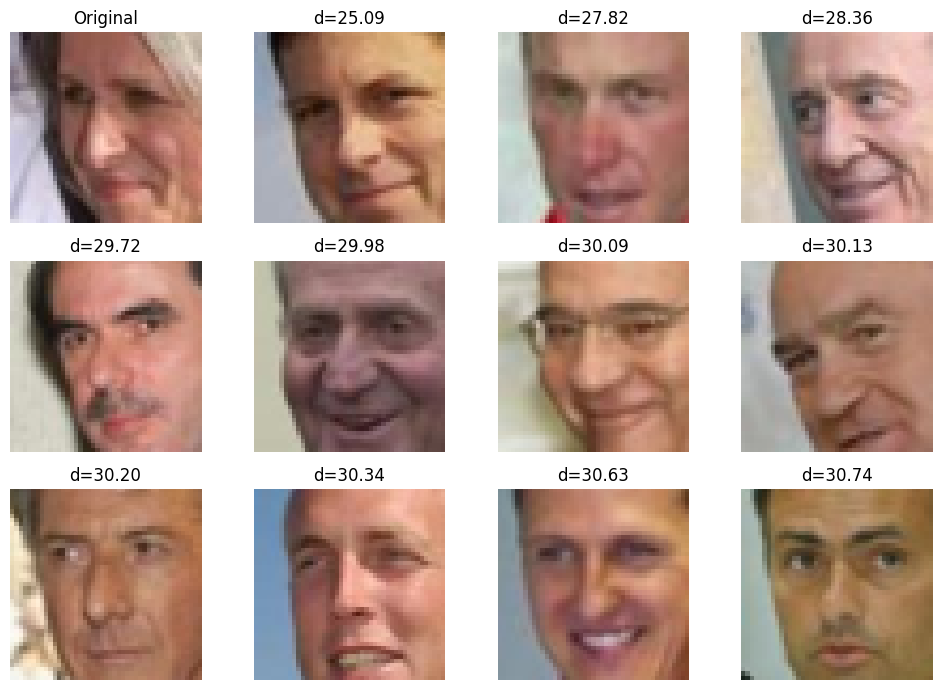

In [240]:
# <тут выведите самые похожие лица к какому-нибудь лицу из тестовой части датасета>

print("# 1")
show_similar(X_val[1])
print("# 2")
show_similar(X_val[2])
print("# 3")
show_similar(X_val[3])